In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import scanpy as sc
import paste as pst
import pandas as pd
import ot
import warnings
warnings.filterwarnings("ignore")

In [2]:
adata=sc.read_visium('/home/dbj/mouse/DLPFC/DLPFC/151674/')
adata.var_names_make_unique()
truth = pd.read_csv('/home/dbj/mouse/vision/spatial/DLPFC_annotations/151674_truth.csv', sep='\t', index_col=0)
adata.obs['truth'] = truth.iloc[:,0]
adata = adata[~adata.obs['truth'].isna(), :]
adata1=adata


adata=sc.read_visium('/home/dbj/mouse/DLPFC/DLPFC/151673/')
adata.var_names_make_unique()
truth = pd.read_csv('/home/dbj/mouse/vision/spatial/DLPFC_annotations/151673_truth.csv', sep='\t', index_col=0)
adata.obs['truth'] = truth.iloc[:,0]
adata = adata[~adata.obs['truth'].isna(), :]
adata2=adata

In [3]:
adata2.X = adata2.X.astype(np.float32)
alpha = 0.1
pi12 = pst.pairwise_align(adata1, adata2, use_gpu=True,
                          backend=ot.backend.TorchBackend(), 
                          alpha=alpha, norm=True, verbose=True)

gpu is available, using gpu.
It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|4.133742e+01|0.000000e+00|0.000000e+00
    1|4.133742e+01|0.000000e+00|0.000000e+00


In [4]:
result = pd.DataFrame(pi12)
matching_index = np.argmax(result.to_numpy(),axis=0)
matching = np.array([np.arange(result.shape[1]),matching_index])
adata1_df = pd.DataFrame({'index': range(adata1.shape[0]),
                        'x': adata1.obsm['spatial'][:,0],
                        'y': adata1.obsm['spatial'][:,1],
                        'celltype': adata1.obs['truth']})
adata2_df = pd.DataFrame({'index': range(adata2.shape[0]),
                        'x': adata2.obsm['spatial'][:,0],
                        'y': adata2.obsm['spatial'][:,1],
                        'celltype': adata2.obs['truth']})

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
# Normalize the x and y coordinates to the range [0, 1]
def normalize_coordinates(df):
    df[['x', 'y']] = (df[['x', 'y']] - df[['x', 'y']].min()) / (df[['x', 'y']].max() - df[['x', 'y']].min())
    return df

adata1_df = normalize_coordinates(adata1_df)
adata2_df = normalize_coordinates(adata2_df)

In [6]:
def plot_matching_flow(
    adata1_df, adata2_df, matching, selected_cell_type, 
    arrow_sample_size_per_type=55, xlim=(0, 1), ylim=(0, 1), height_scale=1.0, save_path=None
):

    fig = plt.figure(figsize=(14, 7))
    ax = fig.add_subplot(111, projection="3d")
    
    matched_indices_adata1 = matching[0]  
    matched_indices_adata2 = matching[1]  
    
    pcloud1 = adata1_df[['x', 'y']].values 
    pcloud2 = adata2_df[['x', 'y']].values  
    adata1_df['celltype'] = adata1_df['celltype'].astype(str)
    adata2_df['celltype'] = adata2_df['celltype'].astype(str)
    celltypes_adata1 = adata1_df['celltype'].values
    celltypes_adata2 = adata2_df['celltype'].values
    
    unique_celltypes_adata1 = np.unique(celltypes_adata1)
    unique_celltypes_adata2 = np.unique(celltypes_adata2)
    unique_celltypes_combined = np.unique(np.concatenate([unique_celltypes_adata1, unique_celltypes_adata2]))

    # Create the color map for the combined unique cell types
    color_map_combined = {celltype: cm.tab20(i / len(unique_celltypes_combined)) 
                          for i, celltype in enumerate(unique_celltypes_combined)}
    
    # Map the colors to the original datasets
    color_map_adata1 = {celltype: color_map_combined[celltype] for celltype in unique_celltypes_adata1}
    color_map_adata2 = {celltype: color_map_combined[celltype] for celltype in unique_celltypes_adata2}

    ax.scatter(
        pcloud2[:, 0], pcloud2[:, 1], np.zeros(pcloud2.shape[0]),c=[color_map_adata2[celltype] for celltype in celltypes_adata2], s=1, alpha=0.6)
    
    ax.scatter(
        pcloud1[:, 0], pcloud1[:, 1], np.ones(pcloud1.shape[0]) * height_scale,c=[color_map_adata1[celltype] for celltype in celltypes_adata1], s=1, alpha=0.6)

    
    # Highlight start points for the selected cell type
    selected_indices_adata1 = np.where(celltypes_adata1 == selected_cell_type)[0]
    blue_points=[]
    valid_pairs = []
    endpoint_labels = []
    for i in range(matching.shape[1]):
        pair = matching[:, i] 
        celltype1 = adata1_df.loc[adata1_df["index"] == pair[1], "celltype"].values[0]
        celltype2 = adata2_df.loc[adata2_df["index"] == pair[0], "celltype"].values[0]
        
        if celltype2 == selected_cell_type:
            valid_pairs.append(pair)
            endpoint_labels.append(celltype1)
    pcloud2_coords = np.array([pcloud2[pair[0]] for pair in valid_pairs])
    pcloud1_coords = np.array([pcloud1[pair[1]] for pair in valid_pairs])
    blue_points.extend([pcloud1[pair[1]] for pair in valid_pairs])
    x_pcloud2 = pcloud2_coords[:, 0]
    y_pcloud2 = pcloud2_coords[:, 1]
    x_pcloud1 = pcloud1_coords[:, 0]
    y_pcloud1 = pcloud1_coords[:, 1]
    ax.scatter(x_pcloud2, y_pcloud2, np.zeros_like(x_pcloud2), c="red", s=2, alpha=1)
    ax.scatter(x_pcloud1, y_pcloud1, np.full_like(x_pcloud1, height_scale), c="blue", s=6, alpha=1)
    
    for i in range(len(valid_pairs)):
        ax.plot(
            [pcloud2[valid_pairs[i][0], 0], pcloud1[valid_pairs[i][1], 0]],
            [pcloud2[valid_pairs[i][0], 1], pcloud1[valid_pairs[i][1], 1]],
            [0, height_scale],
            color="grey", linewidth=0.6, alpha=0.5, linestyle="--"
        )

    ax.view_init(elev=30, azim=-15)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_zlim(0, 2 * height_scale)
    ax.set_title("")
    ax.set_axis_off()
    # ax.legend()  # Remove legend
    if save_path:
        fig.savefig(save_path, dpi=300)
        print(f"Image saved as: {save_path}")

    plt.tight_layout()
    plt.show()
    return np.array(blue_points),np.array(endpoint_labels)

In [7]:
def chamfer_distance(points_a, points_b):
    dists_a_to_b = np.min(np.linalg.norm(points_a[:, np.newaxis] - points_b, axis=2), axis=1)
    dists_b_to_a = np.min(np.linalg.norm(points_b[:, np.newaxis] - points_a, axis=2), axis=1)
    
    return np.mean(dists_a_to_b**2) + np.mean(dists_b_to_a**2)

def calculate_prediction_accuracy(end_labels, expected_end_type):
    total_predictions = len(end_labels)
    is_correct_mask = np.isin(end_labels, expected_end_type)
    correct_count = np.sum(is_correct_mask)
    accuracy = correct_count / total_predictions
    return accuracy

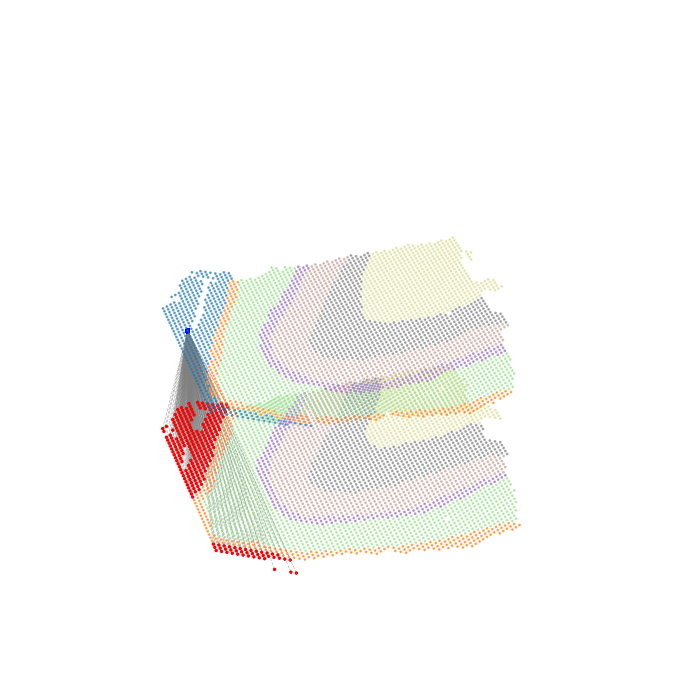

In [8]:
blue_points,endpoint_cell_types=plot_matching_flow(
    adata1_df, adata2_df, matching, selected_cell_type='Layer_1', 
    arrow_sample_size_per_type=355, xlim=(-0.1, 1.1), ylim=(-0.1, 1.1), height_scale=1.0, #save_path='/home/dbj/lib_3d_OT/revise/cross2/brain.png'
)

In [9]:
layer_1_points = adata1_df[adata1_df['celltype'] == 'Layer_1'][['x', 'y']].values
chamfer_dist = chamfer_distance(blue_points, layer_1_points)

print(f"Chamfer distance : {chamfer_dist}")

Chamfer distance : 0.06971042115161982


In [10]:
final_type = ['Layer_1']
CI_score = calculate_prediction_accuracy(endpoint_cell_types, final_type)
CI_score

1.0